<br><br><span style='font-size:50px'>Reading and Discovering the Dataset</span>

<p>Dataset Source: <a href='https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews'>https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews</a></p>

In [54]:
import pandas as pd

In [55]:
data = pd.read_csv('IMDB Dataset.csv')

In [56]:
data.head(20)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [57]:
data.sample(10)

,review,sentiment
7748,The story is extremely unique.It's about these...,positive
1809,The title of my summary pretty much covers my ...,positive
5119,"""Shade"" tries hard to be another ""Sting"", subs...",negative
5275,I know Anime. I've been into it long before it...,positive
5416,I LOVE this film. It was made JUST before the ...,positive
4324,"first off, i'm amazed to see that this film ha...",negative
8630,I remember seeing this film in my late teens o...,positive
5887,I am shocked to see that this movie has been g...,negative
6838,This movie appears to have made for the sole p...,negative
4206,"One the whole, this movie isn't perfect. It do...",positive


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     9999 non-null   object
 1   sentiment  9999 non-null   object
dtypes: object(2)
memory usage: 156.4+ KB


In [59]:
data.duplicated().sum()

17

In [60]:
data = data.drop_duplicates(subset=['review']).reset_index(drop=True)

In [61]:
data['sentiment'].value_counts()

sentiment
positive    5022
negative    4960
Name: count, dtype: int64

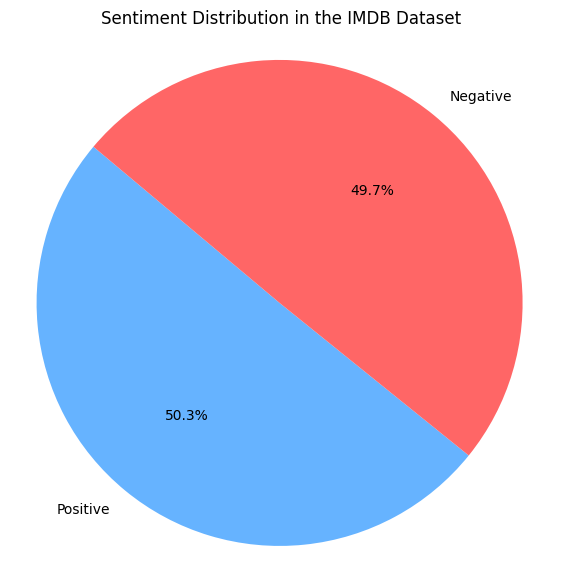

In [62]:
# Distribution of sentiments (Positive vs Negative)
import matplotlib.pyplot as plt

data_dist = [
    len(data[data['sentiment'] == 'positive']),
    len(data[data['sentiment'] == 'negative'])
]
labels = ['Positive', 'Negative']

plt.figure(figsize=(7, 7))
plt.pie(data_dist, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff6666'])
plt.title("Sentiment Distribution in the IMDB Dataset")
plt.axis('equal')
plt.show()

<br><br><span style='font-size:50px'>Data Preprocessing</span>

In [63]:
import re

<br><br><span style='font-size:30px'>Removing HTML Tags</span>

In [64]:
def removeHTML(text):
    text = re.sub(r'<[^>]*>', '', text)
    return(text)

<br><br><span style='font-size:30px'>Removing Stop Words</span>

In [65]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [66]:
from nltk.corpus import stopwords 
stop_words = stopwords.words('english') 

In [67]:
def removeStopWords(text):
    words = text.lower().split()
    filtered_words = [word for word in words if word not in stop_words]
    text = ' '.join(filtered_words)
    return(text)

<br><br><span style='font-size:30px'>Text Lemmatizing</span>

In [68]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [69]:
def Lemmatizing(text):
    text = lemmatizer.lemmatize(text)
    return(text)

<br><br><span style='font-size:30px'>Removing Noise</span>

In [70]:
def removeNoise(text):
    text = re.sub(r'[^a-zA-Z\s]+', '', text) # Only keep English letters
    text = re.sub(r'(\w)\1{2,}', r'\1', text)   #Normalize Repeated Letters
    text = re.sub(r'\s{2,}', ' ', text).strip() # Removing extra spaces
    return(text)

<br><br><br><br><span style='font-size:50px'>Adding New Column for the Cleaned Text</span>

In [71]:
CleanedText = []

In [72]:
for i in range(len(data)):
    text = data.review[i]
    text = removeHTML(text)
    text = removeStopWords(text)
    text = Lemmatizing(text)
    text = removeNoise(text)
    CleanedText.append(text)

In [73]:
data['CleanedText'] = CleanedText

In [74]:
#data = data.drop(['CleanedText'],axis=1)

In [75]:
data.head()

,review,sentiment,CleanedText
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [76]:
data.sample(20)

,review,sentiment,CleanedText
5911,"This film stars, among others, ""SlapChop"" Vinc...",negative,film stars among others slapchop vince offer w...
7569,When I first heard that the subject matter for...,positive,first heard subject matter checking self orche...
8616,"First off, I hadn't seen ""The Blob"" since I wa...",positive,first off seen the blob since viewing adult in...
9652,Amando DeOssorio was never one to let a lack o...,negative,amando deossorio never one let lack budget get...
2704,This was a great film in every sense of the wo...,positive,great film every sense word tackles subject tr...
7155,My 10/10 rating is merely for the fun factor a...,positive,rating merely fun factor assumes decided liked...
9823,Nicely done evil little comedy pitting the FBI...,positive,nicely done evil little comedy pitting fbi org...
4784,The sight of Kareena Kapoor in a two-piece bik...,negative,sight kareena kapoor twopiece bikini thing wak...
2424,"it's a lovely movie ,it deeply reflects the Ch...",positive,lovely movie it deeply reflects chinese underg...
9623,"I have only see three episodes of Hack, starri...",positive,see three episodes hack starring david morse l...


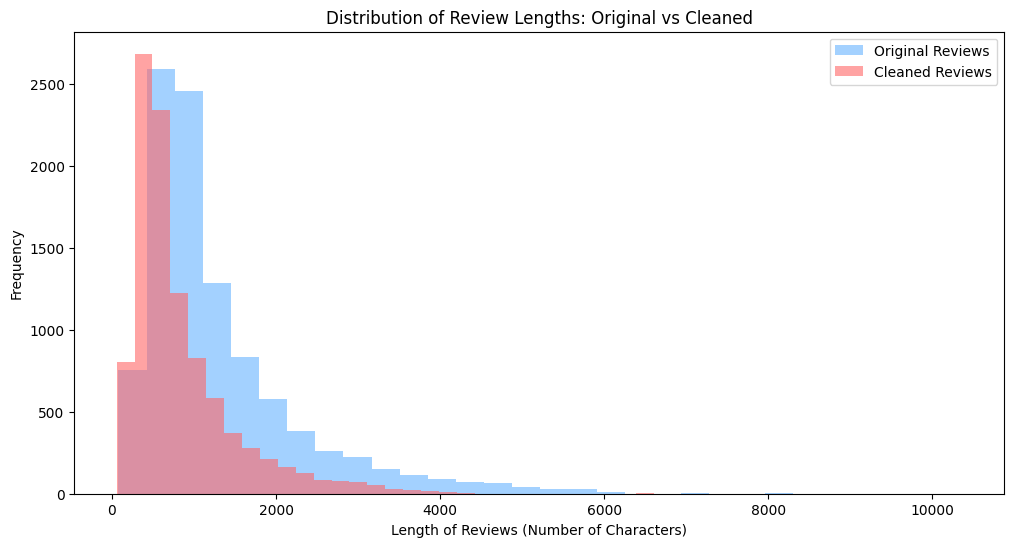

In [77]:

# Visualize the length distribution of the original and cleaned reviews
original_lengths = data['review'].apply(len)
cleaned_lengths = data['CleanedText'].apply(len)

plt.figure(figsize=(12, 6))
plt.hist(original_lengths, bins=30, alpha=0.6, label='Original Reviews', color='#66b3ff')
plt.hist(cleaned_lengths, bins=30, alpha=0.6, label='Cleaned Reviews', color='#ff6666')
plt.xlabel('Length of Reviews (Number of Characters)')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.title('Distribution of Review Lengths: Original vs Cleaned')
plt.show()

<br><br><span style='font-size:50px'>Splitting Data into Training and Testing</span>

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
train, test = train_test_split(data, test_size=0.2, random_state=0)

<br><br><span style='font-size:50px'>Feature Extraction using TF-IDF Vectorizer</span>

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [81]:
X_train = vectorizer.fit_transform(train['CleanedText'])
X_test = vectorizer.transform(test['CleanedText'])

<br><br><span style='font-size:50px'>Model Building & Evaluation</span>

In [82]:
from sklearn.metrics import classification_report,f1_score,accuracy_score

<br><br><span style='font-size:30px'>Multinomial Naive Bayes</span>

In [83]:
from sklearn.naive_bayes import MultinomialNB

In [84]:
mnb = MultinomialNB()

mnb.fit(X_train, train['sentiment'])

MultinomialNB()

In [85]:
pred_y_mnb = mnb.predict(X_test)

In [86]:
print('Classification Report:\n')
print(classification_report(test['sentiment'], pred_y_mnb))
print('_'*100)
print('Accuracy:',accuracy_score(test['sentiment'], pred_y_mnb))
print('_'*100)
print('F1 Score:',f1_score(test['sentiment'], pred_y_mnb, average='weighted'))

Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.87      0.85       984
    positive       0.86      0.83      0.85      1013

    accuracy                           0.85      1997
   macro avg       0.85      0.85      0.85      1997
weighted avg       0.85      0.85      0.85      1997

____________________________________________________________________________________________________
Accuracy: 0.8487731597396094
____________________________________________________________________________________________________
F1 Score: 0.8487601907042183


<br><br><span style='font-size:30px'>Random Forest</span>

In [87]:
from sklearn.ensemble import RandomForestClassifier

In [88]:
rf = RandomForestClassifier(random_state=0, n_jobs=-1, verbose=2)
rf.fit(X_train, train['sentiment'])

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 9 of 100building tree 10 of 100

building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.1s


building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    7.4s finished


RandomForestClassifier(n_jobs=-1, random_state=0, verbose=2)

In [89]:
pred_y_rf = rf.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [90]:
print('Classification Report:\n')
print(classification_report(test['sentiment'], pred_y_rf))
print('_'*100)
print('Accuracy:',accuracy_score(test['sentiment'], pred_y_rf))
print('_'*100)
print('F1 Score:',f1_score(test['sentiment'], pred_y_rf, average='weighted'))

Classification Report:

              precision    recall  f1-score   support

    negative       0.82      0.84      0.83       984
    positive       0.84      0.82      0.83      1013

    accuracy                           0.83      1997
   macro avg       0.83      0.83      0.83      1997
weighted avg       0.83      0.83      0.83      1997

____________________________________________________________________________________________________
Accuracy: 0.8322483725588382
____________________________________________________________________________________________________
F1 Score: 0.8322541774438228


<br><br><span style='font-size:30px'>Logistic Regression</span>

In [91]:

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, train['sentiment'])

pred_y_lr = lr.predict(X_test)

print('Logistic Regression - Classification Report:')
print(classification_report(test['sentiment'], pred_y_lr))
print('_' * 100)
print('Logistic Regression Accuracy:', accuracy_score(test['sentiment'], pred_y_lr))
print('_' * 100)
print('Logistic Regression F1 Score:', f1_score(test['sentiment'], pred_y_lr, average='weighted'))

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.83      0.86       984
    positive       0.85      0.90      0.87      1013

    accuracy                           0.87      1997
   macro avg       0.87      0.87      0.87      1997
weighted avg       0.87      0.87      0.87      1997

____________________________________________________________________________________________________
Logistic Regression Accuracy: 0.8678017025538307
____________________________________________________________________________________________________
Logistic Regression F1 Score: 0.8675714143936084


<br><br><span style='font-size:30px'>SVC</span>

In [92]:

from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=0)

svm.fit(X_train, train['sentiment'])

pred_y_svm = svm.predict(X_test)

print('SVM - Classification Report:')
print(classification_report(test['sentiment'], pred_y_svm))
print('_' * 100)
print('SVM Accuracy:', accuracy_score(test['sentiment'], pred_y_svm))
print('_' * 100)
print('SVM F1 Score:', f1_score(test['sentiment'], pred_y_svm, average='weighted'))


SVM - Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.84      0.86       984
    positive       0.85      0.89      0.87      1013

    accuracy                           0.87      1997
   macro avg       0.87      0.87      0.87      1997
weighted avg       0.87      0.87      0.87      1997

____________________________________________________________________________________________________
SVM Accuracy: 0.8673009514271407
____________________________________________________________________________________________________
SVM F1 Score: 0.867181922479939


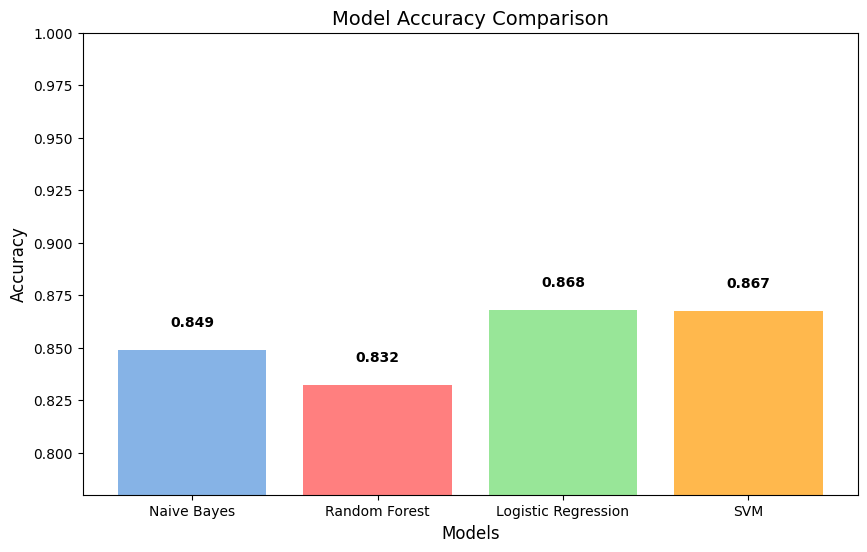

In [93]:
models = ['Naive Bayes', 'Random Forest', 'Logistic Regression', 'SVM']
accuracy_scores = [
    accuracy_score(test['sentiment'], pred_y_mnb),
    accuracy_score(test['sentiment'], pred_y_rf),
    accuracy_score(test['sentiment'], pred_y_lr),
    accuracy_score(test['sentiment'], pred_y_svm)
]

plt.figure(figsize=(10, 6))

bars = plt.bar(models, accuracy_scores, color=['#86b3e6', '#ff7f7f', '#98e698', '#ffb84d'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, round(yval, 3), ha='center', va='bottom', fontweight='bold')

plt.ylim(0.78, 1.0)  # Set the y-axis limits for better detail

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14)

# Show the plot
plt.show()


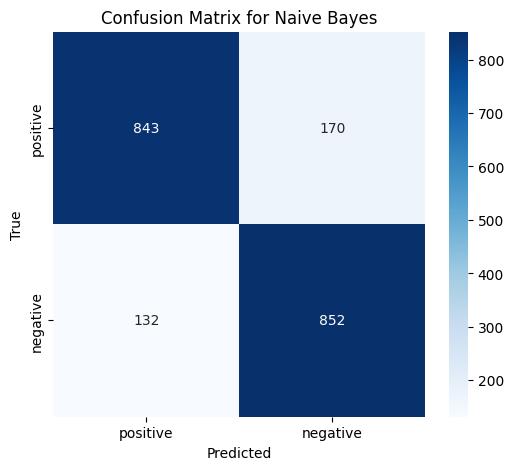

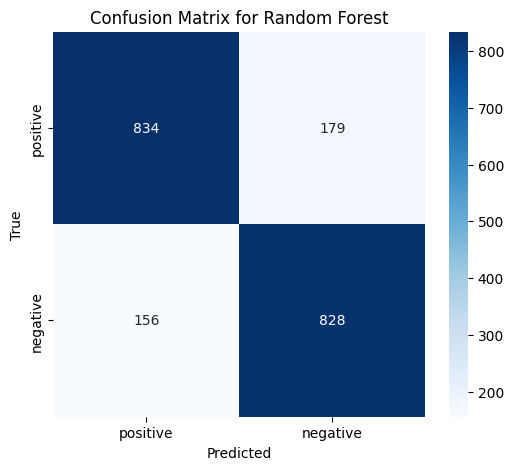

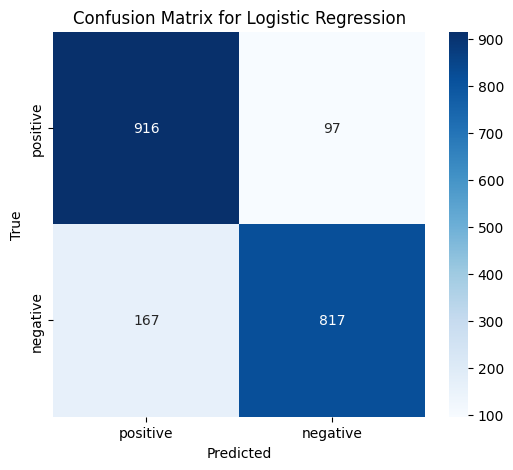

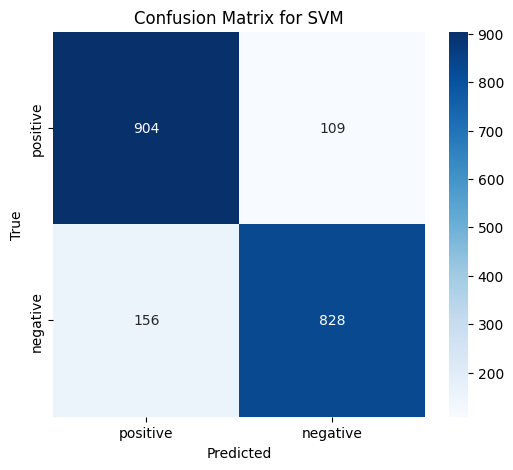

In [94]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(pred_y, model_name):
    cm = confusion_matrix(test['sentiment'], pred_y, labels=['positive', 'negative'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_confusion_matrix(pred_y_mnb, 'Naive Bayes')
plot_confusion_matrix(pred_y_rf, 'Random Forest')
plot_confusion_matrix(pred_y_lr, 'Logistic Regression')
plot_confusion_matrix(pred_y_svm, 'SVM')


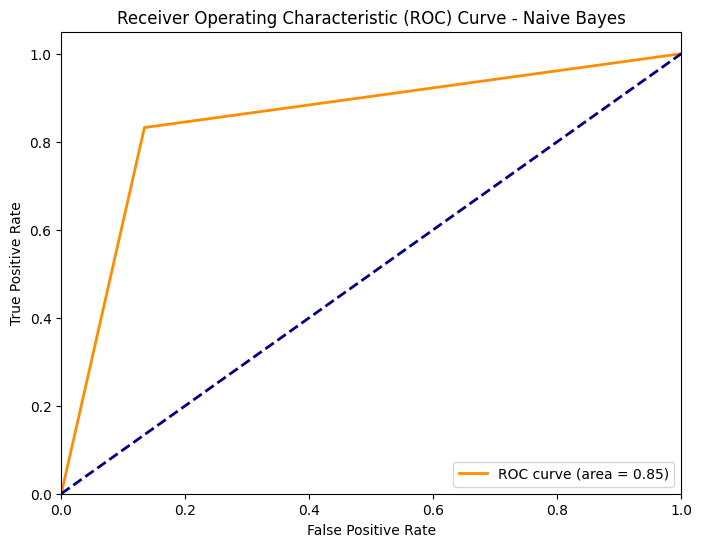

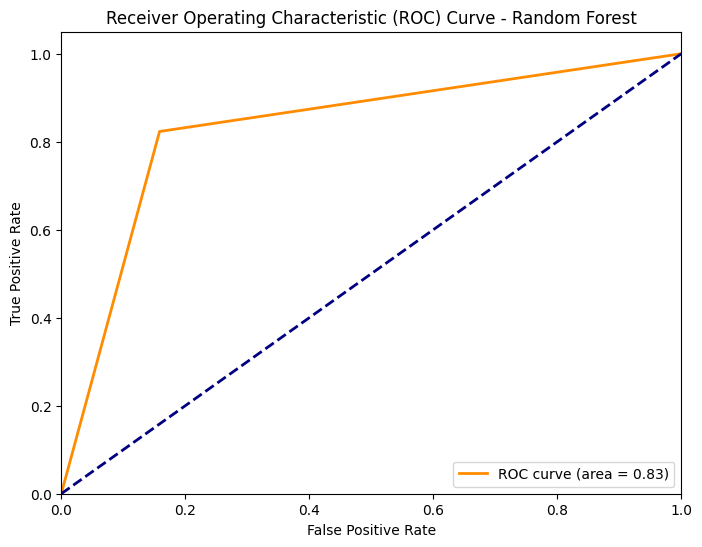

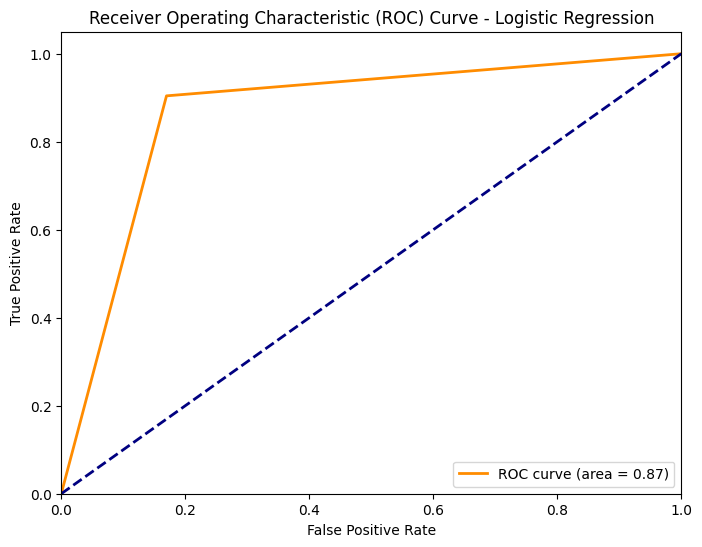

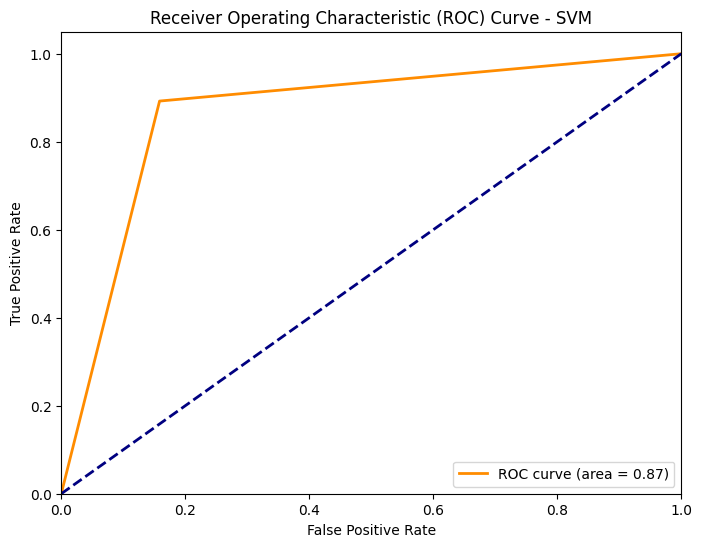

In [95]:

from sklearn.metrics import roc_curve, auc

def plot_roc_curve(pred_y, model_name):
    fpr, tpr, thresholds = roc_curve(test['sentiment'].map({'positive': 1, 'negative': 0}), 
                                      (pred_y == 'positive').astype(int))  # Convert predictions to binary (1 for 'positive', 0 for 'negative')
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.show()

# Plot ROC curve for each classifier
plot_roc_curve(pred_y_mnb, 'Naive Bayes')
plot_roc_curve(pred_y_rf, 'Random Forest')
plot_roc_curve(pred_y_lr, 'Logistic Regression')
plot_roc_curve(pred_y_svm, 'SVM')


<br><br><span style='font-size:50px'>Testing the Model</span>

In [96]:
import numpy as np

In [97]:
from termcolor import colored
from IPython.display import display, HTML

def test_classifier(clf, input_text):
    # Clean the input text
    input_text = removeHTML(input_text)
    input_text = removeStopWords(input_text)
    input_text = Lemmatizing(input_text)
    input_text = removeNoise(input_text)

    # Vectorize the cleaned text
    text_2_vec = vectorizer.transform(np.array([input_text]))    

    # Make the prediction
    pred_y = clf.predict(text_2_vec)

    # Fun output with emojis and colors based on sentiment
    if pred_y == 'positive':
        sentiment_output = "😊 Positive Sentiment"
        review_feedback = "Your review has a positive vibe!  🌟"
        sentiment_color = 'green'
    else:
        sentiment_output = "😞 Negative Sentiment"
        review_feedback = "Oh no! Your review seems to lean towards negativity.  💔"
        sentiment_color = 'red'
    
    # Check if the code is running in a Jupyter notebook environment or not
    try:
        # Try displaying with HTML if in Jupyter (it will fail in terminal-based environments)
        display(HTML(f'<b style="color:{sentiment_color};">{sentiment_output}</b><br><p style="color:{sentiment_color};">{review_feedback}</p>'))
    except:
        # If not in Jupyter, fall back to terminal colors using termcolor
        sentiment_output = colored(sentiment_output, sentiment_color, attrs=['bold'])
        review_feedback = colored(review_feedback, sentiment_color)
        print(sentiment_output)
        print(review_feedback)

# Example input
input_text = '''Lacking coherence and depth, the 2015 "Fantastic Four" adaptation falters with weak
                characterization and a disjointed plot, failing to capture the essence of its source material.'''

print('Text: "' + input_text + '".')

# Testing the classifier
test_classifier(mnb, input_text)


Text: "Lacking coherence and depth, the 2015 "Fantastic Four" adaptation falters with weak
                characterization and a disjointed plot, failing to capture the essence of its source material.".


In [98]:
#Trained Classifiers: mnb, rf

In [99]:
# Input 1: Jurassic Park review
input_text = '''A groundbreaking blend of stunning visuals and thrilling storytelling,
                "Jurassic Park" remains a timeless adventure that defined the blockbuster experience.'''

print('Text: "' + input_text + '".')
print('Sentiment:', test_classifier(mnb, input_text))  # Naive Bayes classifier

Text: "A groundbreaking blend of stunning visuals and thrilling storytelling,
                "Jurassic Park" remains a timeless adventure that defined the blockbuster experience.".


Sentiment: None


In [100]:
# Input 2: The Dark Knight review
input_text = '''An intense, gripping saga showcasing Heath Ledger's mesmerizing performance
                as the Joker. "The Dark Knight" stands as a triumph in the superhero genre, blending action with profound storytelling.'''

print('Text: "' + input_text + '".')
print('Sentiment:', test_classifier(rf, input_text))  # Random Forest classifier


Text: "An intense, gripping saga showcasing Heath Ledger's mesmerizing performance
                as the Joker. "The Dark Knight" stands as a triumph in the superhero genre, blending action with profound storytelling.".


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


Sentiment: None


In [101]:
# Input 3: Suicide Squad review
input_text = '''A disjointed mess with flashes of potential. "Suicide Squad" suffers from an uneven plot, 
                underdeveloped characters, and tonal inconsistencies that undermine its promising premise.'''

print('Text: "' + input_text + '".')
print('Sentiment:', test_classifier(rf, input_text))  # Random Forest classifier

Text: "A disjointed mess with flashes of potential. "Suicide Squad" suffers from an uneven plot, 
                underdeveloped characters, and tonal inconsistencies that undermine its promising premise.".


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


Sentiment: None


In [102]:
# Input 4: The Matrix review
input_text = '''Revolutionary in both visuals and narrative, "The Matrix" is a mind-bending sci-fi classic
                that redefined action cinema, setting new standards for storytelling and special effects.'''

print('Text: "' + input_text + '".')
print('Sentiment:', test_classifier(rf, input_text))  # Random Forest classifier

Text: "Revolutionary in both visuals and narrative, "The Matrix" is a mind-bending sci-fi classic
                that redefined action cinema, setting new standards for storytelling and special effects.".


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


Sentiment: None


In [103]:
# Input 5: Whiplash review
input_text = '''"Whiplash" is a tour de force that resonates deeply. Its intense narrative, fueled by stellar performances and
                an electrifying soundtrack, makes it an unforgettable cinematic experience.'''

print('Text: "' + input_text + '".')
print('Sentiment:', test_classifier(mnb, input_text))  # Naive Bayes classifier

Text: ""Whiplash" is a tour de force that resonates deeply. Its intense narrative, fueled by stellar performances and
                an electrifying soundtrack, makes it an unforgettable cinematic experience.".


Sentiment: None


In [104]:
# Input 6: The Happening review
input_text = '''"M. Night Shyamalan's "The Happening" is a misfire, featuring a disjointed plot 
                and cringe-inducing dialogue. Despite a promising premise, it falls flat, lacking both suspense and coherence.'''

print('Text: "' + input_text + '".')
print('Sentiment:', test_classifier(mnb, input_text))  # Naive Bayes classifier

Text: ""M. Night Shyamalan's "The Happening" is a misfire, featuring a disjointed plot 
                and cringe-inducing dialogue. Despite a promising premise, it falls flat, lacking both suspense and coherence.".


Sentiment: None


In [105]:
input_text="movie was BAD"
print(test_classifier(mnb,input_text))

None
